## ANÁLISE DE DADOS - Portal da Transparência

In [1]:
ano = 2025

caminho_dados = f'/content/drive/MyDrive/AD/{ano}_Viagem.csv'
caminho_saida_tabela = f'/content/drive/MyDrive/AD/output/tabela_{ano}.xlsx'
caminho_saida_grafico = f'/content/drive/MyDrive/AD/output/grafico_{ano}.png'

In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)

# Lendo os dados
df_viagens = pd.read_csv(caminho_dados, encoding="Windows-1252", sep=";", decimal=",")

# Criando nova coluna de despesas
df_viagens['Despesas'] = df_viagens["Valor passagens"] + df_viagens["Valor devolução"] + df_viagens["Valor outros gastos"]

# Ajustando valores nulos na coluna de Cargo
df_viagens['Cargo'] = df_viagens['Cargo'].fillna("Não Identificado")

# Convertendo colunas de data
df_viagens["Período - Data de início"] = pd.to_datetime(df_viagens["Período - Data de início"], format="%d/%m/%Y")
df_viagens["Período - Data de fim"] = pd.to_datetime(df_viagens["Período - Data de fim"], format="%d/%m/%Y")

# Criando novas colunas de data
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Dias de viagem'] = (df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days

In [3]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
0,20150776,060767/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52111,Comando da Aeronáutica,NaN,PETERSON RODRIGUES DA SILVA SANTOS,Não Identificado,Sargento,Sargentos,2025-09-29,2025-10-30,Guaratinguetá/SP,Curso de Preparação de Instrutores para Gradua...,0.00,0.00,0.0,0.00,0.00,September,31
1,20261730,000086/25-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,***.834.907-**,NAZIRA CORREIA CAMELY,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2025-03-01,2025-08-04,Rio Branco/AC,Desenvolvimento da pesquisa que desenvolvo na ...,0.00,0.00,0.0,0.00,0.00,March,156
2,20286869,000002/25,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26241,Universidade Federal do Paraná,***.235.999-**,ALMIR MANOEL CUNICO,PROFESSOR DO MAGISTERIO SUPERIOR,FG-0001,FG-0001,2025-01-25,2025-02-01,Palmas/TO,PARTICIPAÇÃO DO XXV ENCONTRO BRASILEIRO DE ICT...,0.00,2544.74,0.0,0.00,2544.74,January,7
3,20289421,000001/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.396.790-**,ROMULO FABIANO PACHECO RAVAZIO,Não Identificado,OfSuperior,OfSuperior,2025-01-05,2025-01-07,"Bogotá/Colômbia, Uberlândia/MG",Movimentação de militar por término de missão ...,0.00,4329.72,0.0,1240.09,5569.81,January,2
4,20289650,000004/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.329.397-**,ALFREDO DIAS DE OLIVEIRA JUNIOR,Não Identificado,Subtenente,Subtenentes,2025-01-04,2025-01-06,"Londres/Reino Unido, Brasília/DF",Movimentação de militar por término de missão ...,0.00,7109.73,0.0,1053.53,8163.26,January,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789067,2025002522,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.281.438-**,BELLINE SANTANA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2025-12-17,2025-12-19,Sem informação,Participar da reunião do Conselho Fiscal da Ce...,809.09,0.00,0.0,0.00,0.00,December,2
789068,2025002529,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.425.230-**,GILNEU FRANCISCO ASTOLFI VIVAN,DIRETOR SERVIDOR DO BANCO CENTRAL,-1,Sem informação,2025-12-15,2025-12-16,Sem informação,Reuniões de trabalho em São Paulo.,1109.09,5272.59,0.0,0.00,5272.59,December,1
789069,2025002535,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.991.181-**,UVERLAN RODRIGUES PRIMO,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2025-12-09,2025-12-11,Sem informação,Participar em reunião da coordenação do Consel...,858.64,0.00,0.0,0.00,0.00,December,2
789070,2025002573,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.342.565-**,CLIMERIO LEITE PEREIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2025-12-15,2025-12-16,Sem informação,Assessorar Difis em reuniões em SP.,1204.09,5424.29,0.0,0.00,5424.29,December,1


In [4]:
# Criando tabela consolidada
df_viagens_consolidado = (df_viagens
    .groupby('Cargo')
    .agg(
        despesa_media=('Despesas', 'mean'),
        duracao_media=('Dias de viagem', 'mean'),
        despesas_totais=('Despesas', 'sum'),
        destino_mais_frequente=('Destinos', pd.Series.mode),
        n_viagens=('Nome', 'count')
        )
    .reset_index()
    .sort_values(by='despesas_totais', ascending=False))

# Filtrando tabela consolidada por cargos relavantes (> 1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

# Chegando na tabela final - consolidada e filtrada!
df_final = df_viagens_consolidado[filtro].sort_values(by="n_viagens", ascending=False)

# Salvando a tabela final
df_final.to_excel(caminho_saida_tabela, index=False)

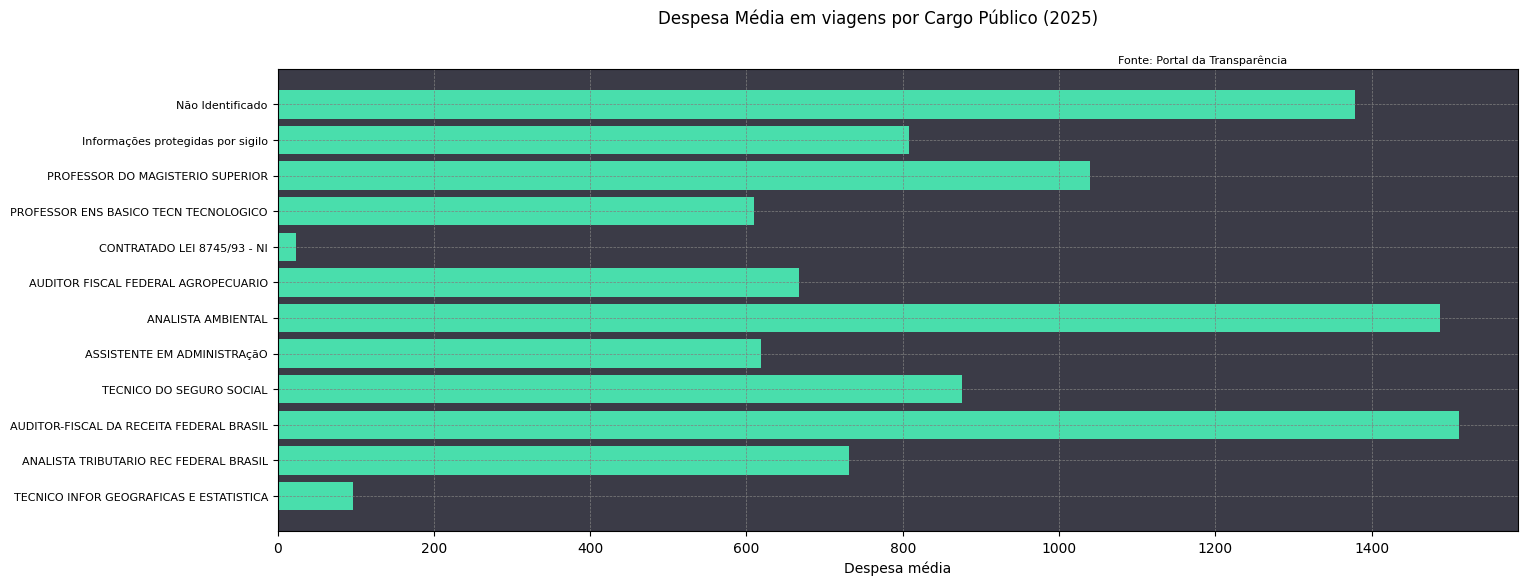

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt

# Criando a figura
fig, ax = plt.subplots(figsize=(16, 6))

# Plotando o gráfico
ax.barh(df_final['Cargo'], df_final['despesa_media'], color="#49deac")
ax.invert_yaxis()

# Ajustando o gráfico
ax.set_facecolor('#3b3b47')
fig.suptitle('Despesa Média em viagens por Cargo Público (2025)')
plt.figtext(0.65, 0.89, 'Fonte: Portal da Transparência', fontsize=8)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=8)
plt.xlabel('Despesa média')

# Exibindo o gráfico
plt.show()

# Salvando o gráfico
plt.savefig(caminho_saida_grafico, bbox_inches = 'tight')


In [7]:
caminho_saida = "/content/drive/MyDrive/AD/output/tabela.xlsx"

In [8]:
df_final.to_excel(caminho_saida)